<a href="https://colab.research.google.com/github/tamyriscabral/lia1_2026_2/blob/main/YOLO/Atividade_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Instalar a biblioteca > Ultralytics**

In [22]:
# Instalar a biblioteca
!pip install -q -U ultralytics

import ultralytics

print("Ultralytics:", ultralytics.__version__)

Ultralytics: 8.4.138


In [23]:
from pathlib import Path

zip_path = Path("/content/brain-tumor.zip")


In [24]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as z:
    arquivos = z.namelist()

print(f"Quantidade de arquivos: {len(arquivos):,}")

for arquivo in arquivos[:30]:
    print(arquivo)

Quantidade de arquivos: 2,225
images/
images/train/
images/train/00054_145.jpg
images/train/00054_164.jpg
images/train/00056_110.jpg
images/train/00056_129.jpg
images/train/00056_147.jpg
images/train/00056_239.jpg
images/train/00056_92.jpg
images/train/00058_102.jpg
images/train/00058_122.jpg
images/train/00058_141.jpg
images/train/00058_179.jpg
images/train/00059_103.jpg
images/train/00059_122.jpg
images/train/00059_141.jpg
images/train/00059_84.jpg
images/train/00060_69.jpg
images/train/00060_70.jpg
images/train/00060_71.jpg
images/train/00060_72.jpg
images/train/00061_108.jpg
images/train/00061_127.jpg
images/train/00061_146.jpg
images/train/00061_184.jpg
images/train/00063_197.jpg
images/train/00063_217.jpg
images/train/00064_101.jpg
images/train/00064_121.jpg
images/train/00064_140.jpg


In [25]:
extract_path = Path("/content/brain-tumor")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extraído com sucesso!")

Dataset extraído com sucesso!


In [26]:
base = Path("/content/brain-tumor")

for pasta in [
    base / "images" / "train",
    base / "images" / "val",
    base / "labels" / "train",
    base / "labels" / "val"
]:
    arquivos = list(pasta.iterdir())
    print(f"{pasta}: {len(arquivos)} arquivos")

/content/brain-tumor/images/train: 893 arquivos
/content/brain-tumor/images/val: 223 arquivos
/content/brain-tumor/labels/train: 878 arquivos
/content/brain-tumor/labels/val: 223 arquivos


In [27]:
from collections import Counter

labels_dir = Path("/content/brain-tumor/labels")

contador = Counter()

for arquivo in labels_dir.rglob("*.txt"):
    with open(arquivo, "r") as f:
        for linha in f:
            linha = linha.strip()
            if linha:
                classe = linha.split()[0]
                contador[classe] += 1

print("Classes encontradas:")
for classe, quantidade in sorted(contador.items()):
    print(f"Classe {classe}: {quantidade} objetos")

Classes encontradas:
Classe 0: 591 objetos
Classe 1: 575 objetos


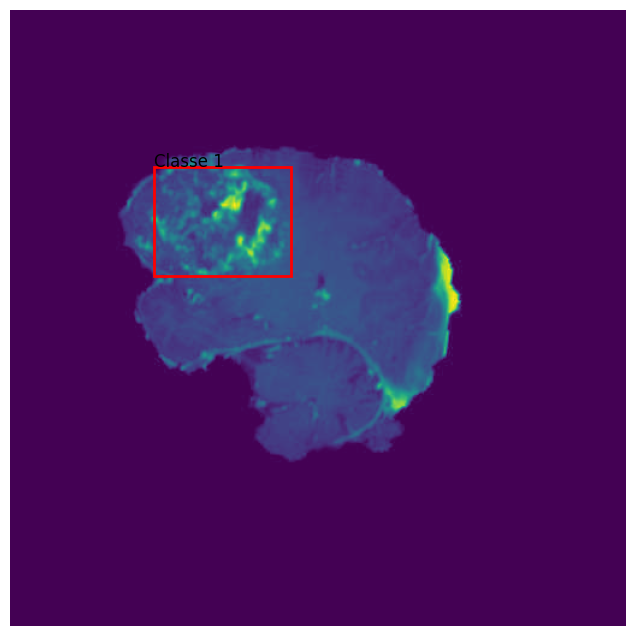

In [28]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

images_dir = Path("/content/brain-tumor/images/train")
labels_dir = Path("/content/brain-tumor/labels/train")

# Escolher a primeira imagem
imagem_path = sorted(images_dir.glob("*"))[0]
label_path = labels_dir / f"{imagem_path.stem}.txt"

# Abrir imagem
img = Image.open(imagem_path)
img_w, img_h = img.size

# Criar figura
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)

# Ler anotações
with open(label_path, "r") as f:
    for linha in f:
        valores = linha.strip().split()

        classe = int(valores[0])
        x_center = float(valores[1])
        y_center = float(valores[2])
        width = float(valores[3])
        height = float(valores[4])

        # YOLO -> coordenadas da imagem
        box_w = width * img_w
        box_h = height * img_h

        x = (x_center * img_w) - box_w / 2
        y = (y_center * img_h) - box_h / 2

        # Desenhar bounding box
        rect = patches.Rectangle(
            (x, y),
            box_w,
            box_h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)
        ax.text(x, y, f"Classe {classe}", fontsize=12)

ax.axis("off")
plt.show()

In [29]:
yaml_content = """
path: /content/brain-tumor

train: images/train
val: images/val

names:
  0: negative
  1: positive
"""

yaml_path = Path("/content/brain-tumor/data.yaml")
yaml_path.write_text(yaml_content)

print(yaml_path.read_text())


path: /content/brain-tumor

train: images/train
val: images/val

names:
  0: negative
  1: positive



In [30]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

print("Modelo carregado!")

Modelo carregado!


In [32]:
results = model.train(
    data="/content/brain-tumor/data.yaml",
    epochs=100,
    imgsz=640
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brain-tumor/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset

In [35]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

In [41]:
results = model.predict(
    "https://ultralytics.com/assets/brain-tumor-sample.jpg",
    conf=0.
)


Found https://ultralytics.com/assets/brain-tumor-sample.jpg locally at brain-tumor-sample.jpg
image 1/1 /content/brain-tumor-sample.jpg: 640x640 1 negative, 11.1ms
Speed: 2.4ms preprocess, 11.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


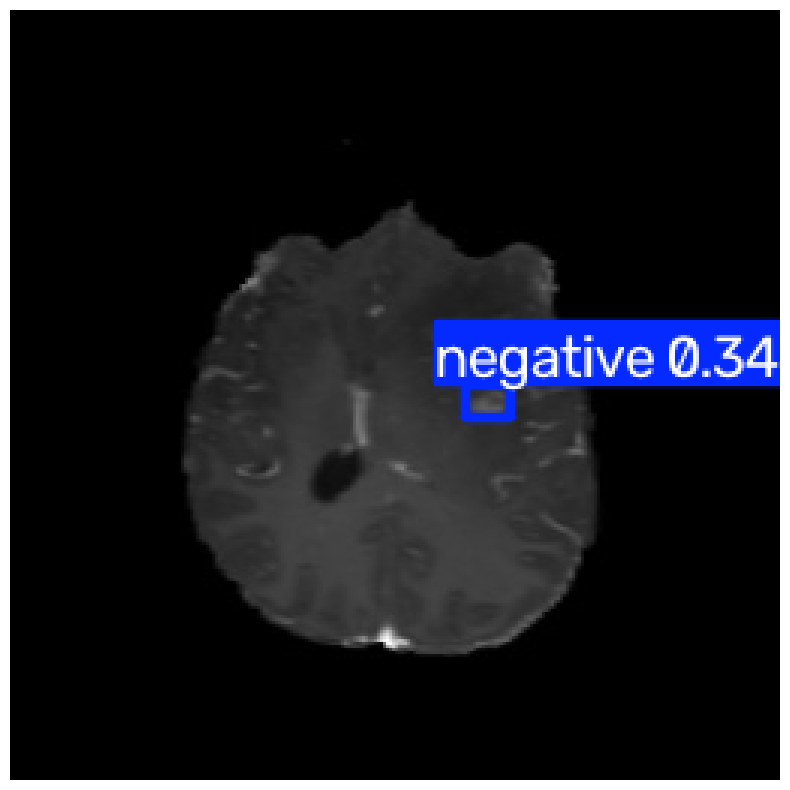

In [42]:
import matplotlib.pyplot as plt

result = results[0]

plt.figure(figsize=(10, 10))
plt.imshow(result.plot()[..., ::-1])
plt.axis("off")
plt.show()

In [43]:
import random
model = YOLO("/content/runs/detect/train/weights/best.pt")

images_dir = Path(
    "/content/kaggle_dataset"
)

selected_images = random.sample(list(images_dir.glob("*.png")), 12)

for confidence in [0.5, 0.3, 0.1]:
    model.predict(
        source=[str(img) for img in selected_images],
        conf=confidence,
        save=True,
        project="/content/runs/sample_test",
        name=f"conf_{confidence}".replace(".", "_")
    )


0: 640x640 (no detections), 4.5ms
1: 640x640 (no detections), 4.5ms
2: 640x640 1 positive, 4.5ms
3: 640x640 (no detections), 4.5ms
4: 640x640 1 positive, 4.5ms
5: 640x640 1 positive, 4.5ms
6: 640x640 2 positives, 4.5ms
7: 640x640 2 positives, 4.5ms
8: 640x640 (no detections), 4.5ms
9: 640x640 (no detections), 4.5ms
10: 640x640 (no detections), 4.5ms
11: 640x640 (no detections), 4.5ms
Speed: 2.0ms preprocess, 4.5ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/sample_test/conf_0_5

0: 640x640 1 positive, 4.3ms
1: 640x640 (no detections), 4.3ms
2: 640x640 1 positive, 4.3ms
3: 640x640 (no detections), 4.3ms
4: 640x640 3 positives, 4.3ms
5: 640x640 1 positive, 4.3ms
6: 640x640 2 positives, 4.3ms
7: 640x640 3 positives, 4.3ms
8: 640x640 (no detections), 4.3ms
9: 640x640 1 positive, 4.3ms
10: 640x640 (no detections), 4.3ms
11: 640x640 1 negative, 1 positive, 4.3ms
Speed: 1.8ms preprocess, 4.3ms inference, 0.3ms postprocess per image at shape

In [46]:
import pandas as pd

rows = []

for confidence in [0.1, 0.3, 0.5]:
    results = model.predict(
        source=[str(img) for img in selected_images],
        conf=confidence,
        verbose=False
    )

    for result in results:
        classes = []

        for box in result.boxes:
            class_id = int(box.cls[0])
            classes.append(result.names[class_id])

        rows.append({
            "Imagem": Path(result.path).name,
            "Confiança": confidence,
            "Resultado": ", ".join(sorted(set(classes))) if classes else "Nenhuma detecção"
        })

df = pd.DataFrame(rows)

tabela = (
    df.pivot(index="Imagem", columns="Confiança", values="Resultado")
      .rename(columns={
          0.1: "Confiança 0.1",
          0.3: "Confiança 0.3",
          0.5: "Confiança 0.5"
      })
      .reset_index()
)

display(tabela)


Confiança,Imagem,Confiança 0.1,Confiança 0.3,Confiança 0.5
0,2758.png,Nenhuma detecção,Nenhuma detecção,Nenhuma detecção
1,2763.png,positive,positive,Nenhuma detecção
2,2788.png,"negative, positive","negative, positive",Nenhuma detecção
3,2792.png,"negative, positive",positive,positive
4,2820.png,positive,positive,positive
5,2825.png,positive,positive,Nenhuma detecção
6,2869.png,"negative, positive",positive,positive
7,2891.png,"negative, positive",positive,positive
8,2893.png,"negative, positive",positive,positive
9,2986.png,Nenhuma detecção,Nenhuma detecção,Nenhuma detecção
